# Несбалансированные выборки. Практическая работа

## Цель практической работы

Научиться обрабатывать несбалансированные данные и обучать модели машинного обучения на таких данных.

## Что входит в работу


1. Загрузить данные и провести разведочный анализ.
2. Разделить данные на обучающую и тестовую выборки.
3. Подготовить данные для моделирования.
4. Сбалансировать данные методом SMOTE и обучить модель машинного обучения.
5. Обучить модель машинного обучения с использованием весов классов и кросс-валидации.
6. Сравнить метрики качества четырёх моделей.




## Что оценивается 

- Выполнены все этапы работы.
- Не допущена утечка данных при разделении выборок и подготовке данных.
- Данные корректным образом сбалансированы.
- Модели не переобучены.


## Как отправить работу на проверку

Скачайте файл с заданиями в материалах, откройте его через Jupyter Notebook и выполните задания. Сохраните изменения при помощи опции Save and Checkpoint из вкладки меню File или кнопки Save and Checkpoint на панели инструментов. Отправьте через форму ниже итоговый файл Jupyter Notebook (в формате .ipynb) или ссылку на него.


# Задача

Пусть у нас имеется некоторый набор данных `german_credit_data.csv` о заёмщиках банка:

* Age — возраст заёмщика.
* Sex — пол заёмщика.
* Job — тип работы заёмщика.
* Housing — тип жилья заёмщика.
* Saving accounts — объём средств на сберегательных счетах заёмщика.
* Checking account — объём средств на основном счёте заёмщика.
* Credit amount — размер кредита. 
* Duration — срок кредита (в месяцах).
* Purpose — цель кредита.
* Risk — таргет, допустил ли заёмщик просрочку платежей по кредиту.

Решите задачу классификации заёмщиков, чтобы банк умел заранее предсказывать просрочку платежей по кредиту. 



# Задание 1

Загрузите датасет и выполните разведочный анализ данных. Сделайте выводы о найденных закономерностях, особенностях и других свойствах данных, которые вы обнаружите.

In [1]:

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [2]:
df = pd.read_csv('german_credit_data.csv')
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


# Задание 2

Разделите датасет на обучающую и тестовую выборки в пропорции 80:20. Разделение должно быть стратифицированным по таргету Risk.

В этом и следующих заданиях используйте random_state = 1.

In [3]:
RANDOM_SEED = 1

df_train, df_test = train_test_split(df, stratify=df['Risk'], test_size=0.2, random_state=RANDOM_SEED)

# Задание 3

Проведите этап очистки и подготовки данных (data preparation) и подготовьте данные к моделированию.

In [4]:
#Смотрим описание признаков
df_train.describe()

,Age,Job,Credit amount,Duration
count,800.000000,800.000000,800.000000,800.000000
mean,35.930000,1.910000,3267.940000,21.117500
std,11.541734,0.648016,2836.325117,12.221002
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1386.500000,12.000000
50%,33.000000,2.000000,2302.500000,18.000000
75%,42.000000,2.000000,3919.000000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


boxplot for Age


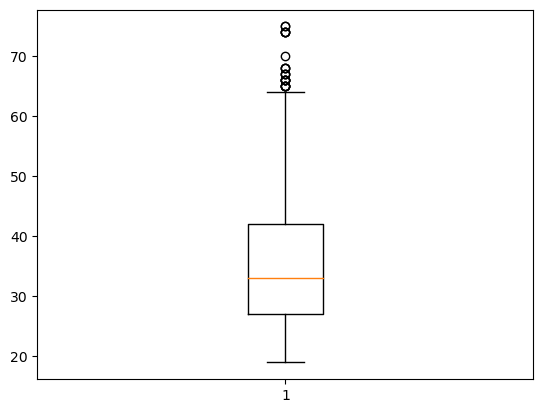

boxplot for Job


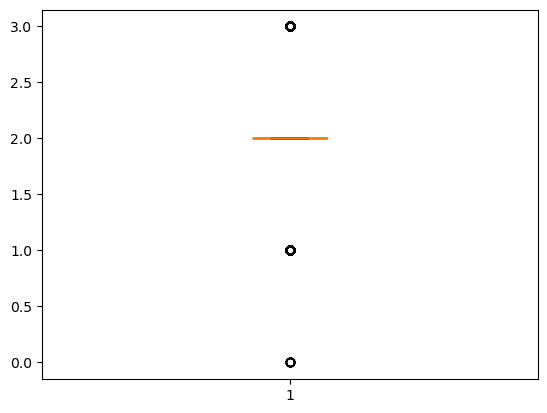

boxplot for Credit amount


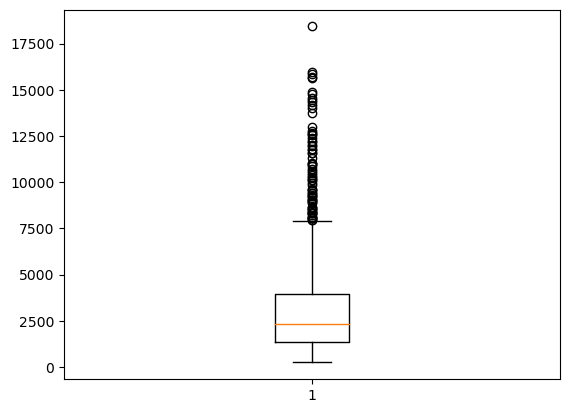

boxplot for Duration


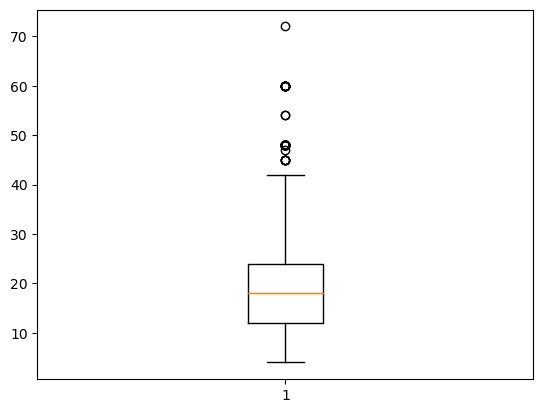

In [5]:
#Проверяем наличие аномалий и выбросов
numerical_features = df_train.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_features:    
    print(f'boxplot for {col}')
    plt.boxplot(df[col])
    plt.show()

In [6]:
#Нормализуем числовые признаки, чтобы минимизировать вляение выбросов и аномалий
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[numerical_features])
X_train = pd.DataFrame(X_train, columns=numerical_features)

X_test = scaler.transform(df_test[numerical_features])
X_test = pd.DataFrame(X_test, columns=numerical_features)

In [7]:
#Закодируем категориальные признаки
categorical_features = df_train.select_dtypes(include=['object']).columns
df_cat = pd.get_dummies(df_train[categorical_features], prefix=categorical_features)
df_cat = df_cat.reset_index()

df_cat_test = pd.get_dummies(df_test[categorical_features], prefix=categorical_features)
df_cat_test = df_cat_test.reset_index()

In [8]:
X_train = pd.concat([X_train, df_cat], axis=1)
X_test = pd.concat([X_test, df_cat_test], axis=1)

In [9]:
#Удалим по одному бинарному признаку
col_to_drop = ['Sex_male', 'Housing_free', 'Saving accounts_little', 
               'Checking account_little', 'Purpose_business', 'Risk_bad']
X_train = X_train.drop(col_to_drop, axis=1)

X_train = X_train.rename(columns={'Risk_good': 'Risk'})

X_test = X_test.drop(col_to_drop, axis=1)

X_test = X_test.rename(columns={'Risk_good': 'Risk'})

In [10]:
y_train = X_train['Risk']
X_train = X_train.drop(['Risk'], axis=1)

y_test = X_test['Risk']
X_test = X_test.drop(['Risk'], axis=1)

In [11]:
#Смотрим на баланс классов
y_train.value_counts()

1    560
0    240
Name: Risk, dtype: int64

# Задание 4

Сбалансируйте обучающую выборку методом SMOTE и обучите модель RandomForestClassifier. Подберите оптимальные гиперпараметры с помощью GridSearch. Посчитайте метрику ROC-AUC на тестовой выборке.

In [12]:
os = SMOTE(random_state=RANDOM_SEED, k_neighbors=2)

X_train_SMOTE, y_train_SMOTE = os.fit_resample(X_train, y_train)

In [13]:
y_train_SMOTE.value_counts()

0    560
1    560
Name: Risk, dtype: int64

In [19]:
params = {
          'n_estimators' : np.arange(60, 120, 10),
          'max_depth' : np.arange(1, 7, 1)
         }

gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_SEED), params, cv=3, scoring='roc_auc', verbose=1)

gs.fit(X_train_SMOTE, y_train_SMOTE)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=1),
             param_grid={'max_depth': array([1, 2, 3, 4, 5, 6]),
                         'n_estimators': array([ 60,  70,  80,  90, 100, 110])},
             scoring='roc_auc', verbose=1)

In [20]:
print("Лучшие параметры для RandomForestRegressor:", gs.best_params_)
print("Лучший результат для RandomForestRegressor:", gs.best_score_)

Лучшие параметры для RandomForestRegressor: {'max_depth': 6, 'n_estimators': 90}
Лучший результат для RandomForestRegressor: 0.7925306807842398


In [21]:
model_rf = RandomForestClassifier(n_estimators=90, max_depth=6, random_state=RANDOM_SEED)
model_rf.fit(X_train, y_train)

print(roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1]))

0.7052380952380952


# Задание 5

Обучите модель RandomForestClassifier с использованием весов классов. Подберите оптимальные веса и гиперпараметры с помощью GridSearch. Посчитайте метрику ROC-AUC на тестовой выборке.

In [22]:
params = {
          'n_estimators' : np.arange(60, 120, 10),
          'max_depth' : np.arange(1, 7, 1)
         }

gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'), 
                  params, cv=3, scoring='roc_auc', verbose=1)

gs.fit(X_train, y_train)

print("Лучшие параметры для RandomForestRegressor:", gs.best_params_)
print("Лучший результат для RandomForestRegressor:", gs.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры для RandomForestRegressor: {'max_depth': 3, 'n_estimators': 100}
Лучший результат для RandomForestRegressor: 0.6412197161366991


In [24]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_SEED)
model_rf.fit(X_train, y_train)

print(roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1]))

0.6892857142857144
